<a href="https://colab.research.google.com/github/DemydovaAnna/python_for_da_tasks/blob/main/Copy_of_HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Dataloveacademy/Модуль 11. Візуалізація даних для аналізу з бібліотеками matplotlib, seaborn, plotly/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

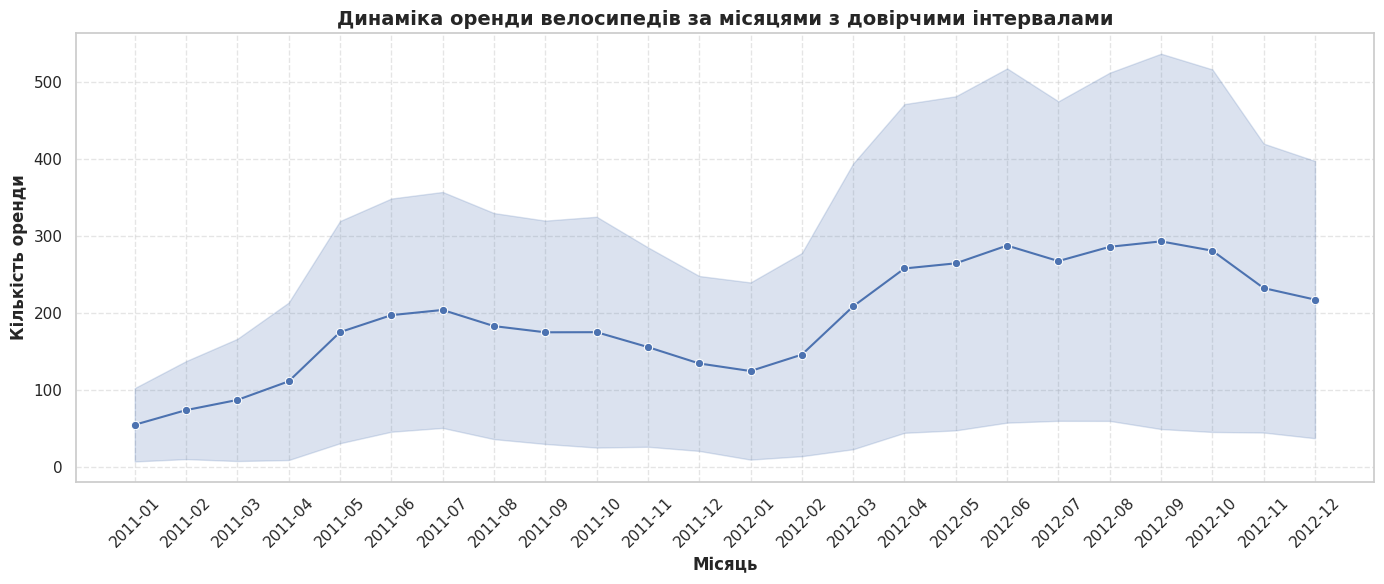

In [6]:
plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    marker='o',
    errorbar='sd'
)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами', fontsize=14, fontweight='bold')
plt.xlabel('Місяць', fontsize=12, fontweight='bold')
plt.ylabel('Кількість оренди', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**В які місяці найбільша невизначеність в даних?**

Найбільша невизначеність спостерігається у літній та ранній осінній періоди (червень - вересень / 2012-06 - 2012-09). У ці місяці розкид кількості оренд найвищий через коливання попиту в теплі дні та вихідні.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

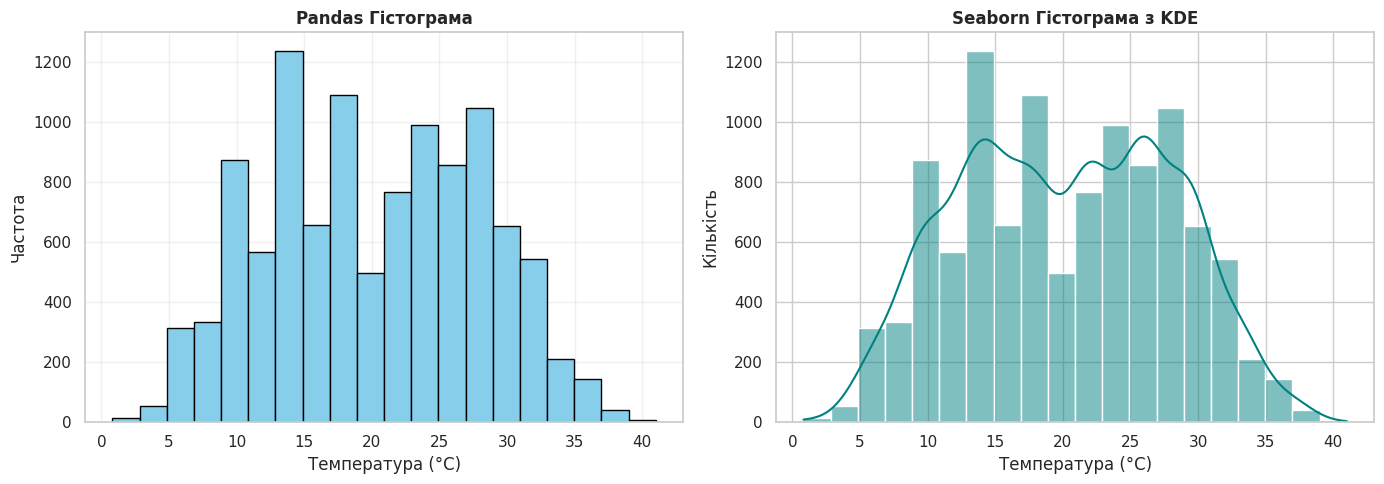

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#1. Гістограма Pandas
df['temp'].plot(kind='hist', bins=20, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Pandas Гістограма', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Температура (°C)')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

#2. Гістограма Seaborn з оцінкою щільності (kde=True)
sns.histplot(df['temp'], bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Seaborn Гістограма з KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Температура (°C)')
axes[1].set_ylabel('Кількість')

plt.tight_layout()
plt.show()

1. Яка візуальна різниця між Pandas та Seaborn гістограмами?

Seaborn за замовчуванням має сучасніший та приємніший дизайн, автоматично підбирає палітру та адаптує межі, а також дозволяє легко додавати згладжену криву розподілу.

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

Ця лінія називається KDE - Оцінка щільності ядра.
Це плавна згладжена лінія, яка показує загальну форму розподілу даних та де знаходяться його основні піки без прив'язки до ширини окремих стовпчиків.


## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

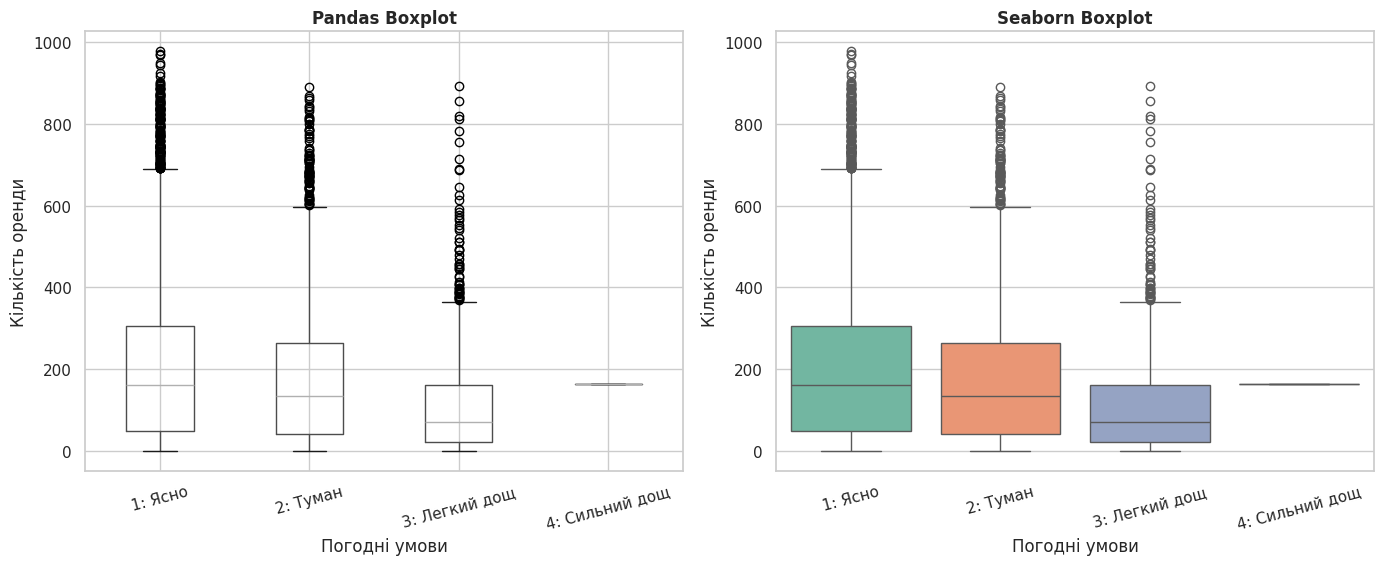

In [10]:
weather_labels = {
    1: '1: Ясно',
    2: '2: Туман',
    3: '3: Легкий дощ',
    4: '4: Сильний дощ'
}
df['weather_label'] = df['weather'].map(weather_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#1. Boxplot Pandas
df.boxplot(column='count', by='weather_label', ax=axes[0])
axes[0].set_title('Pandas Boxplot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренди')
axes[0].tick_params(axis='x', rotation=15)
plt.suptitle('')

#2. Boxplot Seaborn
sns.boxplot(data=df, x='weather_label', y='count', ax=axes[1], hue='weather_label', palette='Set2', legend=False)
axes[1].set_title('Seaborn Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренди')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

Seaborn бокс-плоти візуально виглядають значно виразніше завдяки автоматичній кольоровій палітрі (⁠palette⁠), акуратнішому відображенню викидів (outliers) та гнучкому налаштуванню підписів осей без створення зайвих надзаголовків.


<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


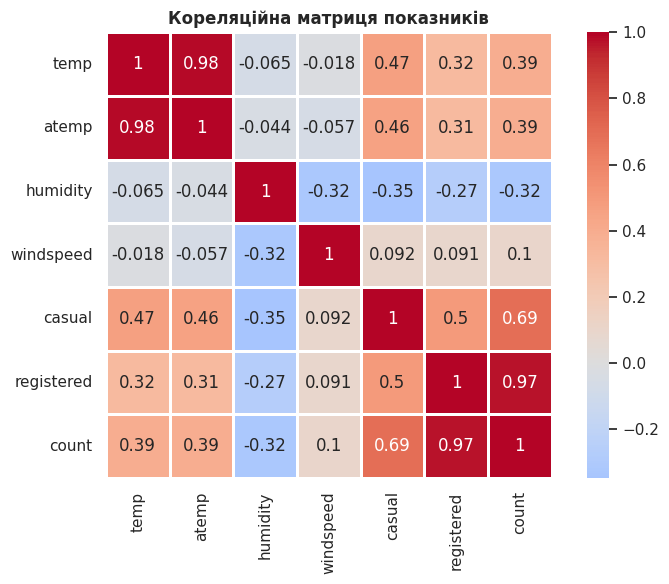

In [12]:
plt.figure(figsize=(8, 6))

numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
correlation = df[numeric_cols].corr()

sns.heatmap( correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )
plt.title('Кореляційна матриця показників', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

Найсильніше корелює ⁠registered⁠ (0.97) та ⁠casual⁠ (0.69).

2. Яка кореляція між temp та atemp? Чому?

Кореляція становить 0.98. Це пояснюється тим, що реальна температура та температура, яка відчувається, мають пряму залежність.

3. Які змінні мають негативну кореляцію?

 З ⁠count⁠ негативну кореляцію має вологість ⁠humidity⁠ (-0.32), зі зростанням вологості кількість оренд зменшується.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


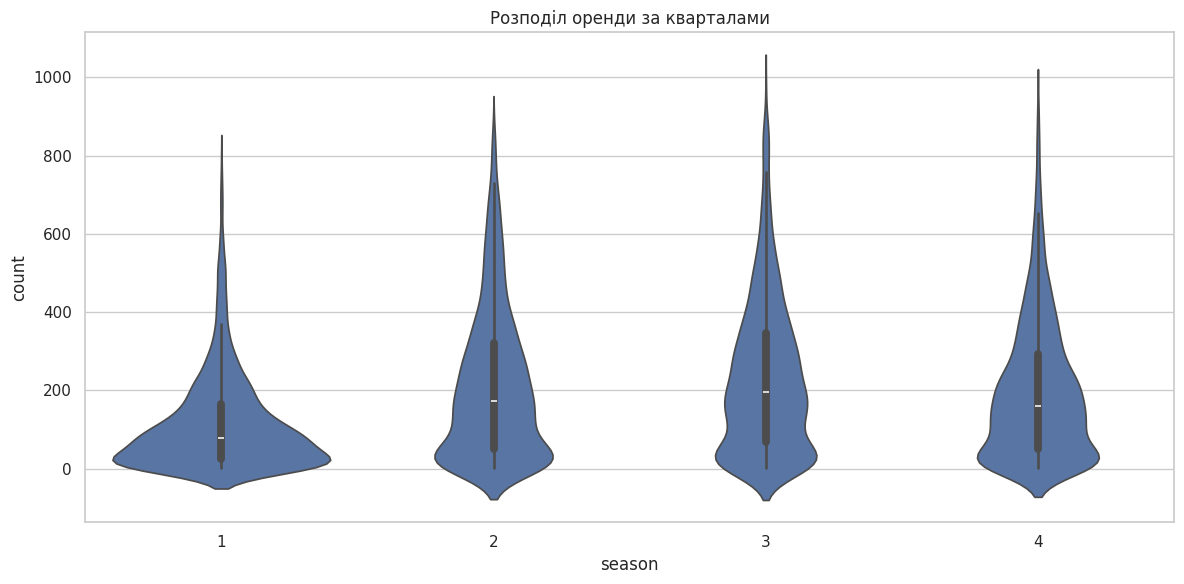

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count')

plt.title('Розподіл оренди за кварталами')
plt.tight_layout()
plt.show()

1. Що показує "товщина" violin plot?

Товщина графіку відображає щільність розподілу даних (оцінку KDE): чим ширша ділянка на певному рівні, тим частіше трапляється саме така кількість оренд.

2. В якому кварталі найбільша варіабельність оренди?

У 3-му кварталі, оскільки скрипка найбільш розтягнута по вертикалі, що вказує на великий розкид значень від мінімуму до максимуму.

3. Яка перевага violin plot над звичайним box plot?

Violin plot наочно показує реальну форму розподілу та наявність декількох піків (мультимодальність), тоді як box plot показує лише 5 базових статистичних чисел (медіану, квартилі, мінімум/максимум).


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

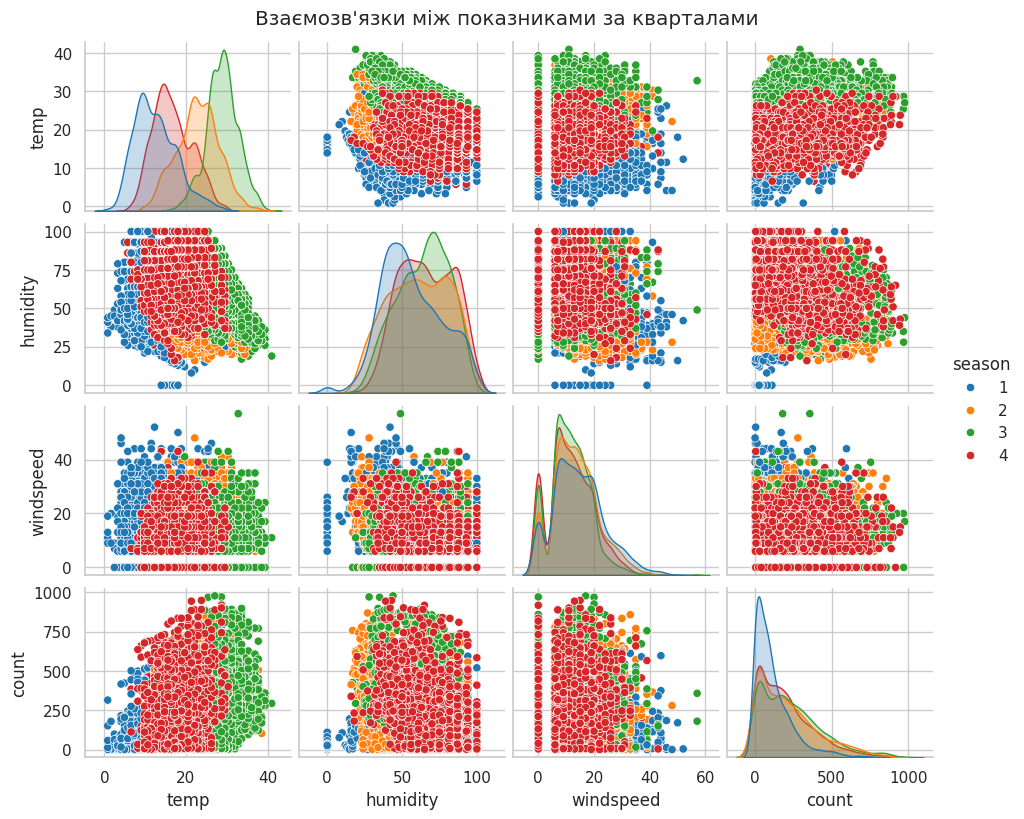

In [15]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]
sns.pairplot(sample_df, hue='season', palette='tab10', height=2.0, aspect=1.2)
plt.suptitle("Взаємозв'язки між показниками за кварталами", y=1.02)
plt.show()

1. Між якими змінними спостерігається найсильніший лінійний зв'язок?

Найсильніший позитивний лінійний зв'язок спостерігається між температурою (⁠temp⁠) та загальною кількістю оренди (⁠count⁠).

2. Яка характеристика найбільше відрізняється між кварталами?

Температура (⁠temp⁠). Вона найбільше відрізняється за сезонами: взимку (Q1) значення значно нижчі, а влітку (Q3) найвищі. Це також сильно впливає на загальну кількість оренди (⁠count⁠).


## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

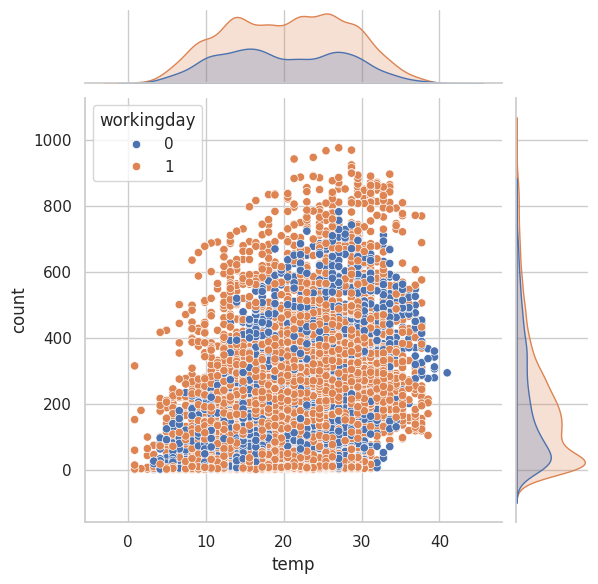

In [16]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday");

1. Що показують графіки по краях?

Графіки на краях (гістограми/KDE) показують одномірні розподіли кожної змінної окремо: зверху - розподіл температури (⁠temp⁠), праворуч - розподіл кількості оренд (⁠count⁠).

2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

В цілому тренд зростання оренди з підвищенням температури є однаковим для обох типів днів. Проте у робочі дні (⁠workingday = 1⁠) спостерігається більша щільність високих значень оренди за сприятливої температури через регулярні поїздки на роботу.
